# cw_metric_init: zero vs ones for the diagonal metric EMAs

The kl-diag-polar (PoLoRA) protagonist stores diagonal curvature metrics $P=\mathrm{diag}(D_{\mathrm{out}})$ and $Q=\mathrm{diag}(D_{\mathrm{in}})$ as EMAs (Alg., metric-update phase):
$$Q_t = \beta_2 Q_{t-1} + (1-\beta_2)\,\tfrac1r\,\mathrm{diag}\!\left(G_A^\top C_A^{-1} G_A\right),\qquad C_A = B^\top \bar P B,$$
consumed only through the max-normalized $\bar Q_t = Q_t/\lambda_{\max}(Q_t)$ (the `_rdinv` `xmax` division), so the scale of $Q_t$ does not enter the direction.

- **zero** (shipped/paper): $Q_0=0$. Step 1 hits the `_rdinv` `xmax`$\approx 0$ fallback $\to$ identity metric (the "step-one rule"); from step 2 on the $(1-\beta_2)$ scale cancels under max-normalization, so $\bar Q_t$ is the pure measured shape.
- **ones**: $Q_0=\mathbf 1$. Step 1 normalizes the all-ones EMA to the *same* identity metric with no special case; the EMA then carries a decaying $\beta_2^{\,t}\mathbf 1$ identity prior on the curvature shape, $Q_t = \beta_2^{\,t}\mathbf 1 + (1-\beta_2)\sum_{s\le t}\beta_2^{t-s} m_s$.

The two give an identical step-1 update (verified to $\sim 10^{-7}$ in `tests/test_cw_metric_init.py`) and converge once $\beta_2^{\,t}\to 0$; with the production $\beta_2=0.99$ the prior is $<10^{-2}$ by step $\approx 460$, so they differ only over the first few hundred warmup steps.

Setting: Llama-3.2-1B, OpenMathInstruct-2 packed seq2048, $r=256$, 9000 steps, precond_delta $=10^{-4}$, seed 0. The `zero` arm is the existing hero protagonist (`fig:hero` / `e1_kldiag_llama32_openmath_r256`); the `ones` arm is the ablation sweep. Runs predating the knob have no `cw_metric_init` field and default to `zero`.

A third arm, **delta**, initializes at the damping floor $Q_0=P_0=\delta I$ ($\varepsilon=\delta$): step 1 normalizes to the same identity metric without the $\texttt{xmax}\approx0$ special-case branch, and the $\varepsilon I$ prior strength $\delta/(1-\beta_2)\approx0.01$ is negligible. It is the branch-free init under consideration as the default; it should overlay **zero** to sub-noise while **ones** (prior strength $\approx100$) diverges through the warmup.

In [43]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, '/mnt/home/nghosh/lora')
import numpy as np
import matplotlib.pyplot as plt
from lora_playground.loader import load_runs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
# COMPUTE: load every protagonist-config run at the hero setting, split by cw_metric_init.
# cw_metric_init is NOT pinned, so both zero (existing) and ones (ablation) load; runs
# predating the knob have no field and default to 'zero'.
WHERE = {
    'optimizer': 'kl-diag-polar-lora', 'lora_r': 256,
    'data_dir': 'data/openmath_instruct_2_2m_packed_seq2048_llama32',
    'model_name': 'meta-llama/Llama-3.2-1B', 'precond_delta': 1e-4, 'beta1': 0.9,
    'precond_method': 'gram_ns', 'cw_nesterov': True, 'cw_picard_iters': 1,
    'rdinv_variant': 'A', 'cw_no_diag_curv': False,
    'cw_factor_a': 0.0, 'cw_factor_b': 0.0, 'max_steps': 9000,
}
runs = load_runs(where=WHERE, quiet=True, warn_cross_commit=False)

def _label(cfg):
    v = cfg.get('cw_metric_init')
    v = v if v in ('zero', 'ones', 'delta') else 'zero'
    gc = (cfg.get('git_commit') or '')[:7]
    return f'{v}@{gc}'   # commit-aware: e1-zero (064a219, pre bias-correction-drop) stays distinct

traj = {}
for cfg, evals in runs:
    lr = float(cfg.get('lr'))
    pts = [(e['step'], e['eval_loss']) for e in evals
           if isinstance(e, dict) and e.get('eval_loss') is not None and e.get('step') is not None]
    if not pts: continue
    pts.sort(); s, l = zip(*pts); traj[(_label(cfg), lr)] = (np.array(s), np.array(l))

LABELS = sorted({lab for (lab, _) in traj})
_pal = ['#6a1b9a', '#ef6c00', '#00695c', '#1f77b4', '#d62728', '#8c564b', '#17becf']
COL = {lab: _pal[i % len(_pal)] for i, lab in enumerate(LABELS)}
print(f'{len(traj)} (label, lr) trajectories; labels = {LABELS}')
for (lab, lr) in sorted(traj, key=lambda k: (k[0], k[1])):
    s, l = traj[(lab, lr)]
    print(f'  {lab:5s} lr={lr:<7g} n={len(l):3d} max_step={s.max():5d} final={l[-1]:.4f} min={l.min():.4f}')

10 (label, lr) trajectories; labels = ['delta@cdc5576', 'ones@52d33d3', 'zero@064a219', 'zero@9b69f74', 'zero@ecb4db2']
  delta@cdc5576 lr=0.003   n= 10 max_step= 2500 final=0.4150 min=0.4150
  delta@cdc5576 lr=0.01    n= 10 max_step= 2500 final=0.4123 min=0.4123
  delta@cdc5576 lr=0.03    n= 10 max_step= 2500 final=0.4382 min=0.4382
  ones@52d33d3 lr=0.003   n= 17 max_step= 4250 final=0.3957 min=0.3957
  ones@52d33d3 lr=0.01    n= 17 max_step= 4250 final=0.3940 min=0.3940
  ones@52d33d3 lr=0.03    n= 17 max_step= 4250 final=0.4177 min=0.4177
  zero@064a219 lr=0.003   n= 36 max_step= 9000 final=0.3759 min=0.3759
  zero@064a219 lr=0.03    n= 36 max_step= 9000 final=0.3684 min=0.3684
  zero@9b69f74 lr=0.1     n= 36 max_step= 9000 final=0.3991 min=0.3991
  zero@ecb4db2 lr=0.01    n= 36 max_step= 9000 final=0.3644 min=0.3644


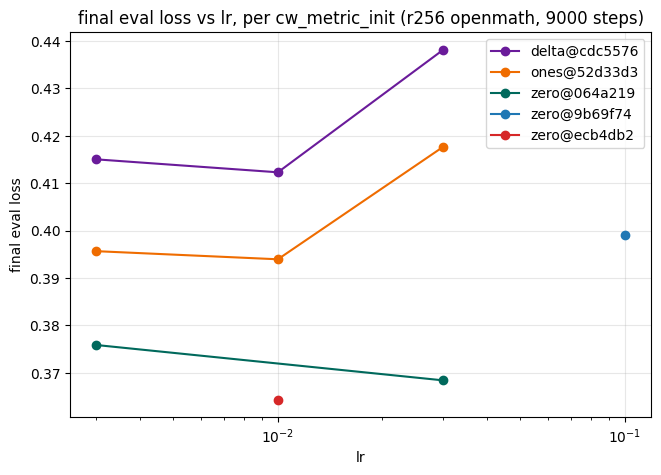

In [45]:
# PLOT 1: final eval loss vs lr, per init.
fig, ax = plt.subplots(figsize=(7.5, 5))
for lab in LABELS:
    lrs = sorted(lr for (l, lr) in traj if l == lab)
    if not lrs: continue
    ax.plot(lrs, [traj[(lab, lr)][1][-1] for lr in lrs], '-o', color=COL[lab], label=lab)
ax.set_xscale('log'); ax.set_xlabel('lr'); ax.set_ylabel('final eval loss')
ax.set_title('final eval loss vs lr, per cw_metric_init (r256 openmath, 9000 steps)')
ax.legend(); ax.grid(alpha=0.3); plt.show()

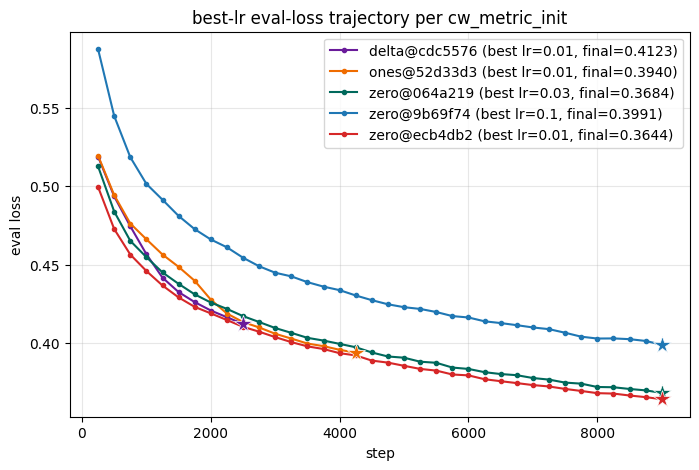

In [46]:
# PLOT 2: best-lr eval-loss trajectory per init, with the marked optimal lr.
fig, ax = plt.subplots(figsize=(8, 5))
for lab in LABELS:
    cells_ = [(lr, traj[(lab, lr)]) for (l, lr) in traj if l == lab]
    if not cells_: continue
    best_lr, (s, l) = min(cells_, key=lambda c: c[1][1][-1])
    ax.plot(s, l, '-o', ms=3, color=COL[lab], label=f'{lab} (best lr={best_lr:g}, final={l[-1]:.4f})')
    ax.plot([s[-1]], [l[-1]], '*', ms=13, color=COL[lab], mec='white', mew=0.5, zorder=5)
ax.set_xlabel('step'); ax.set_ylabel('eval loss')
ax.set_title('best-lr eval-loss trajectory per cw_metric_init')
ax.legend(); ax.grid(alpha=0.3); plt.show()

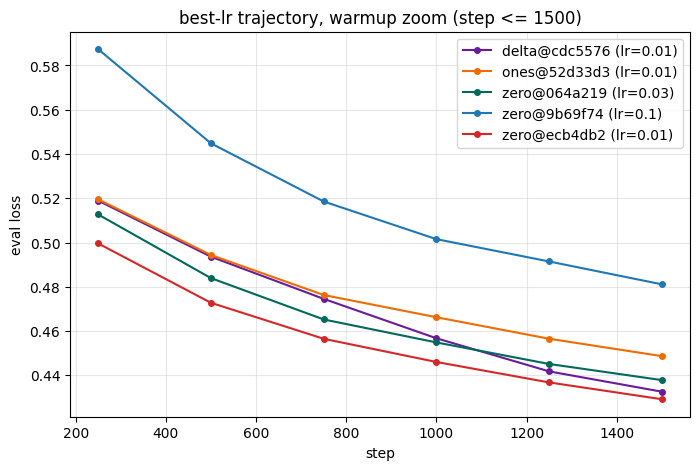

In [47]:
# PLOT 3: warmup zoom of the best-lr trajectories (the transient is the first few hundred steps).
fig, ax = plt.subplots(figsize=(8, 5))
for lab in LABELS:
    cells_ = [(lr, traj[(lab, lr)]) for (l, lr) in traj if l == lab]
    if not cells_: continue
    best_lr, (s, l) = min(cells_, key=lambda c: c[1][1][-1])
    m = s <= 1500
    ax.plot(s[m], l[m], '-o', ms=4, color=COL[lab], label=f'{lab} (lr={best_lr:g})')
ax.set_xlabel('step'); ax.set_ylabel('eval loss')
ax.set_title('best-lr trajectory, warmup zoom (step <= 1500)')
ax.legend(); ax.grid(alpha=0.3); plt.show()

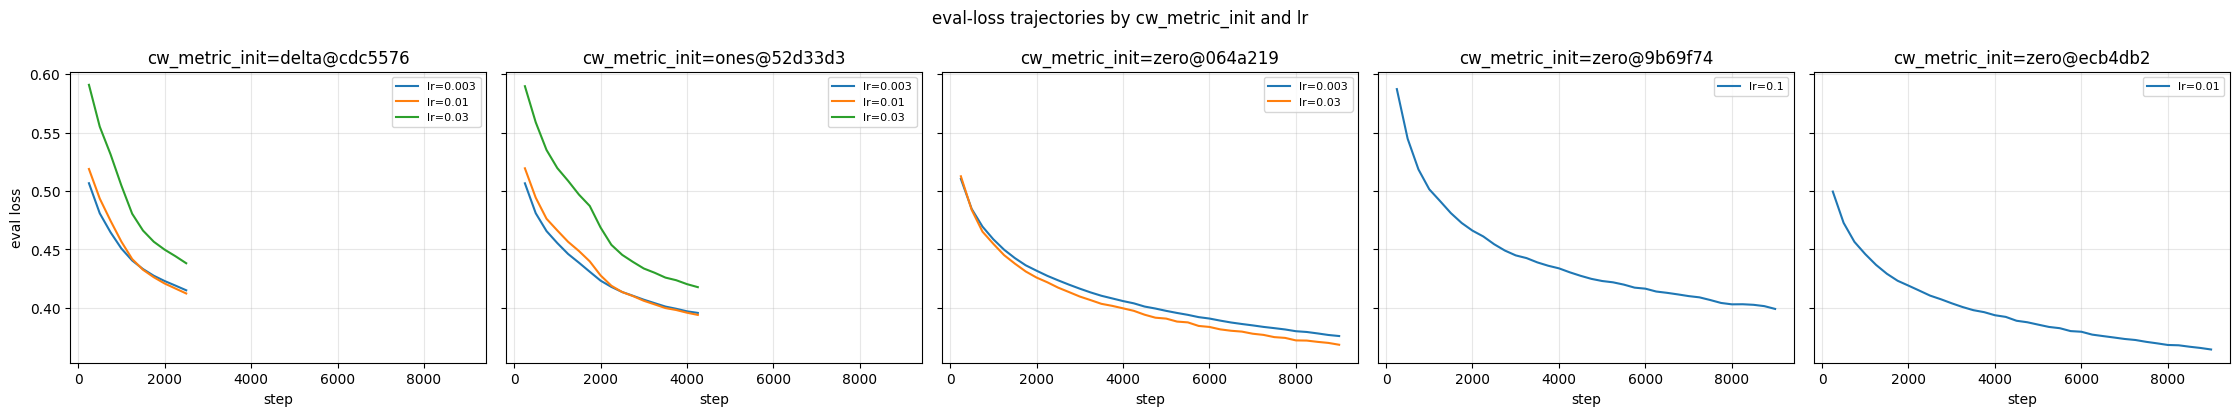

In [48]:
# PLOT 4: all (init, lr) trajectories faceted by init.
ncol = max(1, len(LABELS))
fig, axes = plt.subplots(1, ncol, figsize=(4.5*ncol, 4.2), sharex=True, sharey=True, squeeze=False)
axes = axes[0]
for ax, lab in zip(axes, LABELS):
    for lr in sorted(lr for (l, lr) in traj if l == lab):
        s, l = traj[(lab, lr)]; ax.plot(s, l, '-', label=f'lr={lr:g}')
    ax.set_title(f'cw_metric_init={lab}'); ax.set_xlabel('step'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
axes[0].set_ylabel('eval loss')
fig.suptitle('eval-loss trajectories by cw_metric_init and lr'); fig.tight_layout(); plt.show()